# **1. Perkenalan Dataset**

Dataset yang digunakan pada proyek ini adalah **Credit Score Classification Dataset**
yang bersumber dari Kaggle: https://www.kaggle.com/datasets/parisrohan/credit-score-classification

Dataset ini berisi data finansial dan riwayat kredit nasabah, dengan tujuan
mengklasifikasikan **skor kredit** seorang individu ke dalam salah satu dari tiga
kategori: `Poor`, `Standard`, atau `Good`. Dataset ini relevan untuk
permasalahan dunia nyata di sektor finansial, yaitu penilaian risiko kredit
calon peminjam.

**Sumber Dataset:** Public repository (Kaggle)
**Jumlah Baris:** ±5.000+ baris (subset representatif)
**Jumlah Kolom:** 25 kolom (24 fitur + 1 target `Credit_Score`)

# **2. Import Library**

Pada tahap ini, kita mengimpor seluruh library yang dibutuhkan untuk EDA, preprocessing, dan persiapan data sebelum pemodelan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Library berhasil diimpor")

Library berhasil diimpor


# **3. Memuat Dataset**

Dataset dimuat dari berkas CSV `credit_score_data.csv` yang terletak pada folder `credit_scoring_raw/`.

In [2]:
df = pd.read_csv('../credit_scoring_raw/credit_score_data.csv')

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (5020, 25)


,ID,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,8270,5,52,Engineer,134192.25,13672.73,5,1,10,5,59,3,24.88,11,Bad,4450.33,20.25,8 Years and 10 Months,Yes,1356.62,34.29,High_spent_Large_value_payments,331.11,Poor
1,2,1860,4,40,Accountant,17880.06,12471.23,8,6,13,5,50,23,12.49,3,Standard,599.11,32.22,19 Years and 10 Months,No,1406.89,143.75,Low_spent_Large_value_payments,148.09,Poor
2,3,6390,8,66,Developer,103443.84,6129.23,4,7,13,2,34,14,24.42,13,Good,913.08,45.13,16 Years and 6 Months,Yes,86.41,859.17,High_spent_Large_value_payments,639.11,Standard
3,4,6191,5,25,Mechanic,89388.55,10985.65,3,0,22,7,40,10,3.82,9,Bad,1645.99,41.27,20 Years and 4 Months,NM,212.44,15.22,High_spent_Small_value_payments,1145.03,Poor
4,5,6734,4,45,Scientist,167733.19,6413.10,5,5,9,2,1,8,8.64,9,Bad,3251.48,32.65,20 Years and 9 Months,No,1323.34,406.92,Low_spent_Medium_value_payments,1184.57,Poor


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        5020 non-null   int64  
 1   Customer_ID               5020 non-null   int64  
 2   Month                     5020 non-null   int64  
 3   Age                       5020 non-null   int64  
 4   Occupation                5020 non-null   str    
 5   Annual_Income             5020 non-null   float64
 6   Monthly_Inhand_Salary     4870 non-null   float64
 7   Num_Bank_Accounts         5020 non-null   int64  
 8   Num_Credit_Card           5020 non-null   int64  
 9   Interest_Rate             5020 non-null   int64  
 10  Num_of_Loan               5020 non-null   int64  
 11  Delay_from_due_date       5020 non-null   int64  
 12  Num_of_Delayed_Payment    5020 non-null   int64  
 13  Changed_Credit_Limit      5020 non-null   float64
 14  Num_Credit_Inquirie

In [4]:
df.describe()

,ID,Customer_ID,Month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000,4870.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000
mean,2501.113745,5482.056773,4.458765,43.382669,95707.441859,8084.889018,5.073904,4.603586,17.505976,4.042231,26.957968,12.032271,12.599701,7.040040,2531.733028,34.986954,751.638805,995.436745,740.283928
std,1442.854767,2576.389819,2.302682,14.934498,48943.220164,4120.364795,2.549278,2.862984,9.894349,2.580331,18.962312,7.229023,10.025574,4.305456,1455.520238,8.704904,427.181692,573.752319,432.513968
min,1.000000,1001.000000,1.000000,18.000000,10042.920000,800.680000,1.000000,0.000000,1.000000,0.000000,-5.000000,0.000000,-5.000000,0.000000,0.240000,20.000000,0.420000,1.720000,0.040000
25%,1250.750000,3229.750000,2.000000,31.000000,53296.305000,4529.275000,3.000000,2.000000,9.000000,2.000000,10.000000,6.000000,4.110000,3.000000,1286.087500,27.365000,390.067500,495.255000,356.997500
50%,2502.500000,5495.500000,4.000000,43.000000,96472.050000,8146.715000,5.000000,5.000000,18.000000,4.000000,27.000000,12.000000,12.495000,7.000000,2500.475000,34.945000,747.620000,998.275000,741.570000
75%,3752.250000,7707.250000,6.000000,56.000000,138345.675000,11635.585000,7.000000,7.000000,26.000000,6.000000,43.000000,18.000000,21.340000,11.000000,3816.285000,42.690000,1112.822500,1491.135000,1110.117500
max,5000.000000,9996.000000,8.000000,69.000000,179987.220000,14998.590000,9.000000,9.000000,34.000000,8.000000,59.000000,24.000000,30.000000,14.000000,4999.480000,49.990000,1499.560000,1999.260000,1499.960000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, dilakukan eksplorasi untuk memahami karakteristik data, termasuk distribusi target, missing values, duplikasi, dan hubungan antar fitur.

Credit_Score
Poor        3038
Standard    1595
Good         387
Name: count, dtype: int64

Credit_Score
Poor        60.52
Standard    31.77
Good         7.71
Name: proportion, dtype: float64


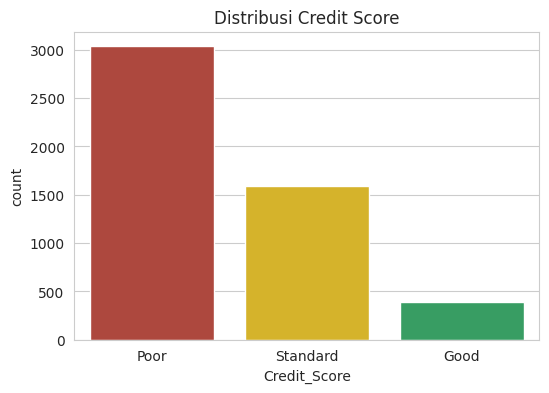

In [5]:
# Distribusi kelas target
print(df['Credit_Score'].value_counts())
print()
print(df['Credit_Score'].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Credit_Score', order=['Poor', 'Standard', 'Good'],
              palette={'Poor': '#C0392B', 'Standard': '#F1C40F', 'Good': '#27AE60'})
plt.title('Distribusi Credit Score')
plt.show()

In [6]:
# Cek missing values
print("Missing values per kolom:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per kolom:
Monthly_Inhand_Salary    150
dtype: int64


In [7]:
# Cek data duplikat
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 20


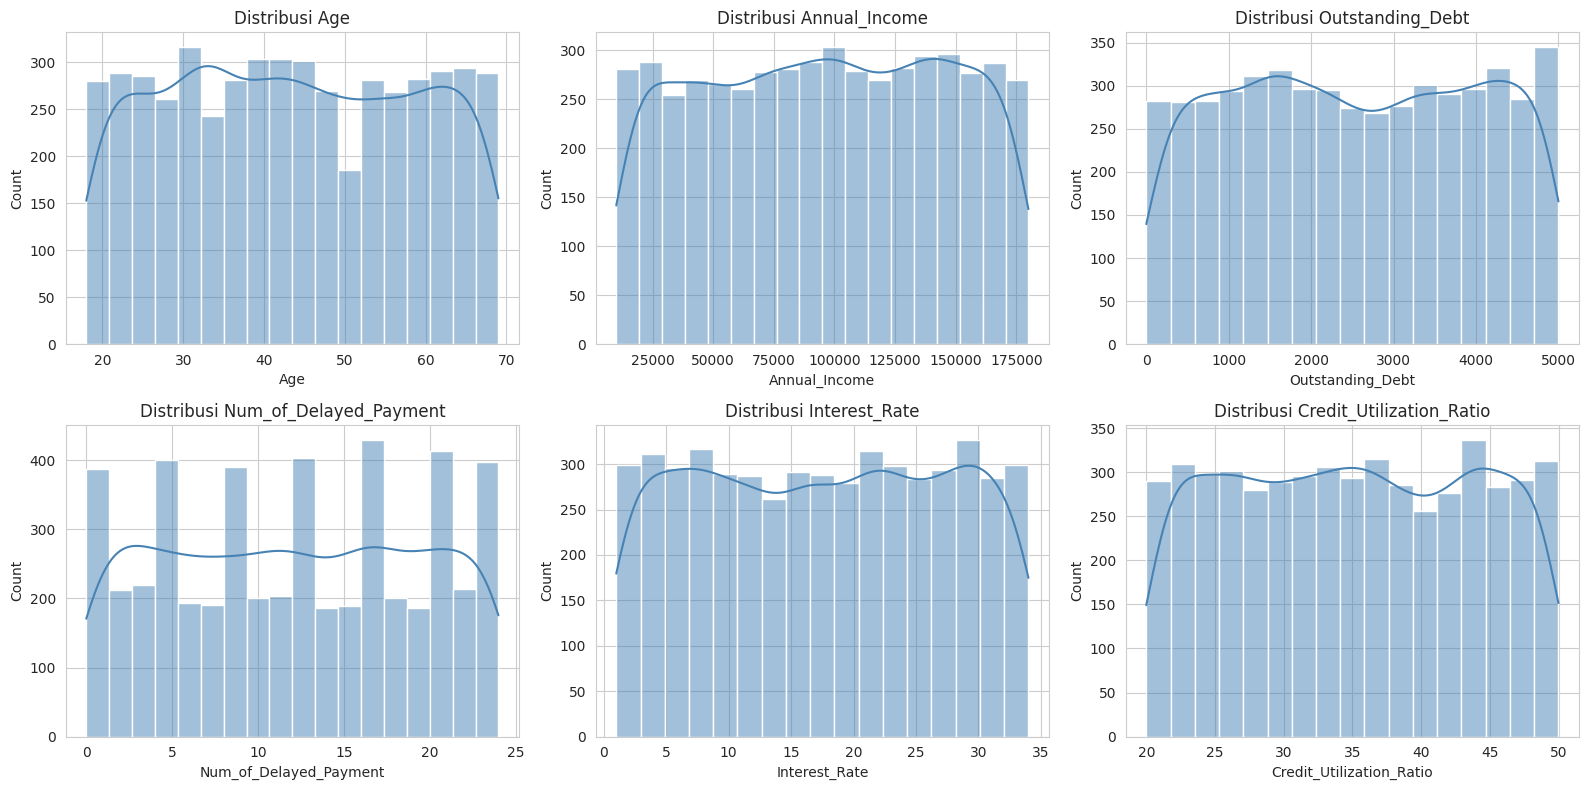

In [8]:
# Distribusi beberapa fitur numerik penting
numeric_cols = ['Age', 'Annual_Income', 'Outstanding_Debt', 'Num_of_Delayed_Payment',
                'Interest_Rate', 'Credit_Utilization_Ratio']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

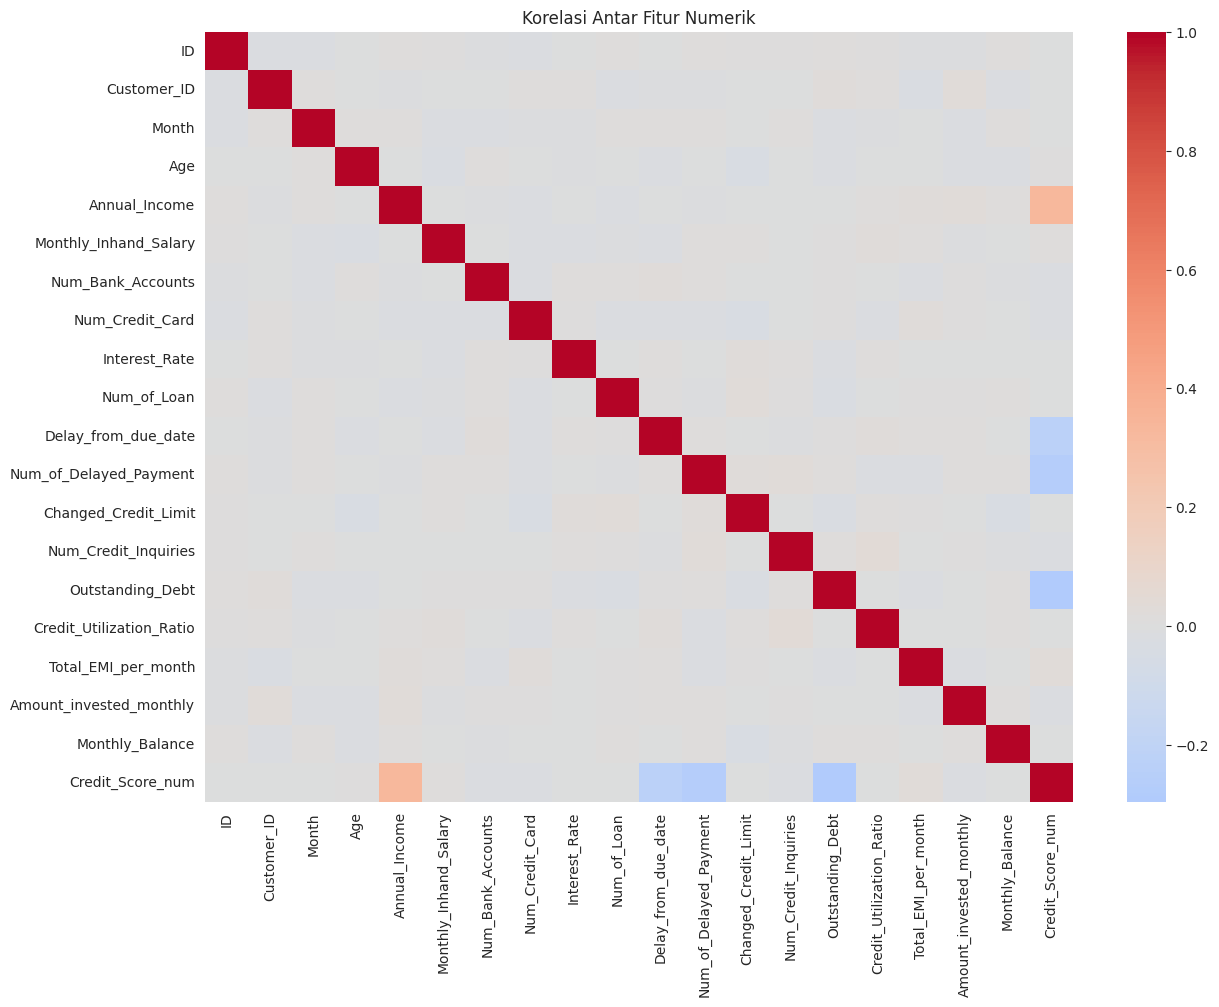

In [9]:
# Korelasi fitur numerik dengan target (setelah encoding sederhana untuk visualisasi)
df_corr = df.copy()
df_corr['Credit_Score_num'] = df_corr['Credit_Score'].map({'Poor': 0, 'Standard': 1, 'Good': 2})

numeric_features = df_corr.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(14, 10))
sns.heatmap(df_corr[numeric_features].corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

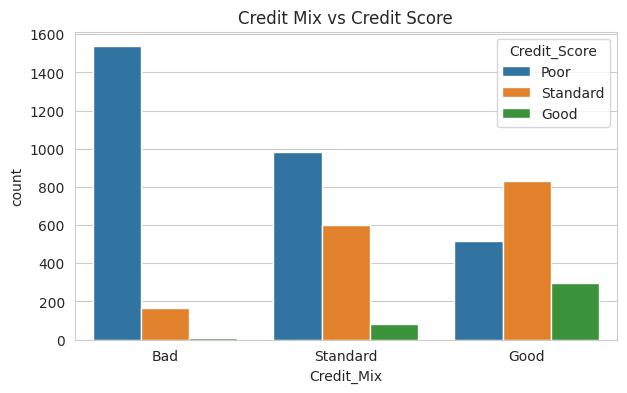

In [10]:
# Hubungan Credit_Mix dengan Credit_Score
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Credit_Mix', hue='Credit_Score',
              order=['Bad', 'Standard', 'Good'],
              hue_order=['Poor', 'Standard', 'Good'])
plt.title('Credit Mix vs Credit Score')
plt.show()

**Insight dari EDA:**
- Distribusi kelas target tidak seimbang, didominasi kategori `Poor`.
- Terdapat sejumlah kecil missing values pada kolom `Monthly_Inhand_Salary`.
- Terdapat baris duplikat yang perlu dibersihkan.
- `Credit_Mix` menunjukkan hubungan yang cukup jelas dengan `Credit_Score` — nasabah
  dengan Credit_Mix "Good" cenderung memiliki Credit_Score yang lebih baik.
- Beberapa fitur finansial seperti `Outstanding_Debt` dan `Num_of_Delayed_Payment`
  menunjukkan korelasi terhadap skor kredit, sesuai intuisi domain.

# **5. Data Preprocessing**

Berdasarkan hasil EDA, dilakukan tahapan preprocessing berikut:
1. Menghapus kolom yang tidak relevan untuk pemodelan (ID, Customer_ID, Name, SSN — jika ada)
2. Menangani missing values
3. Menghapus data duplikat
4. Encoding fitur kategorikal
5. Standarisasi fitur numerik
6. Split data menjadi train dan test set

In [11]:
# 1. Hapus kolom yang tidak relevan untuk pemodelan
cols_to_drop = [c for c in ['ID', 'Customer_ID', 'Name', 'SSN', 'Month'] if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)

print("Kolom yang dihapus:", cols_to_drop)
print("Sisa kolom:", df_clean.shape[1])

Kolom yang dihapus: ['ID', 'Customer_ID', 'Month']
Sisa kolom: 22


In [12]:
# 2. Menangani missing values - imputasi median untuk numerik
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Sisa missing values:", df_clean.isnull().sum().sum())

Sisa missing values: 0


In [13]:
# 3. Menghapus data duplikat
print("Sebelum:", df_clean.shape)
df_clean = df_clean.drop_duplicates()
print("Setelah:", df_clean.shape)

Sebelum: (5020, 22)
Setelah: (5000, 22)


In [14]:
# 4. Parsing kolom Credit_History_Age (format teks "X Years and Y Months") menjadi numerik (bulan)
def parse_credit_history_age(text):
    try:
        years = int(text.split(' Years')[0])
        months = int(text.split('and ')[1].split(' Months')[0])
        return years * 12 + months
    except Exception:
        return np.nan

df_clean['Credit_History_Age_Months'] = df_clean['Credit_History_Age'].apply(parse_credit_history_age)
df_clean = df_clean.drop(columns=['Credit_History_Age'])
df_clean['Credit_History_Age_Months'] = df_clean['Credit_History_Age_Months'].fillna(
    df_clean['Credit_History_Age_Months'].median()
)

df_clean[['Credit_History_Age_Months']].describe()

,Credit_History_Age_Months
count,5000.000000
mean,177.722400
std,104.136811
min,0.000000
25%,90.000000
50%,176.000000
75%,267.000000
max,359.000000


In [15]:
# 5. Encoding fitur kategorikal
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Credit_Score')  # target tidak diencode di sini

print("Kolom kategorikal yang akan diencode:", categorical_cols)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

df_clean.head()

Kolom kategorikal yang akan diencode: ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Age_Months
0,52,4,134192.25,13672.73,5,1,10,5,59,3,24.88,11,0,4450.33,20.25,2,1356.62,34.29,0,331.11,Poor,106
1,40,0,17880.06,12471.23,8,6,13,5,50,23,12.49,3,2,599.11,32.22,1,1406.89,143.75,3,148.09,Poor,238
2,66,2,103443.84,6129.23,4,7,13,2,34,14,24.42,13,1,913.08,45.13,2,86.41,859.17,0,639.11,Standard,198
3,25,8,89388.55,10985.65,3,0,22,7,40,10,3.82,9,0,1645.99,41.27,0,212.44,15.22,2,1145.03,Poor,244
4,45,9,167733.19,6413.10,5,5,9,2,1,8,8.64,9,0,3251.48,32.65,1,1323.34,406.92,4,1184.57,Poor,249


In [16]:
# 6. Encoding target
target_encoder = LabelEncoder()
df_clean['Credit_Score'] = target_encoder.fit_transform(df_clean['Credit_Score'])

print("Mapping target:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

Mapping target: {'Good': np.int64(0), 'Poor': np.int64(1), 'Standard': np.int64(2)}


In [17]:
# 7. Standarisasi fitur numerik
feature_cols = [c for c in df_clean.columns if c != 'Credit_Score']

scaler = StandardScaler()
df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])

df_clean.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Age_Months
0,0.579314,-0.444221,0.786144,1.376561,-0.027545,-1.257190,-0.758512,0.371839,1.689831,-1.249383,1.224153,0.918756,-1.212166,1.318535,-1.694007,1.233547,1.414556,-1.675154,-1.427994,-0.945702,1,-0.688801
1,-0.224563,-1.602554,-1.590350,1.080397,1.149580,0.488519,-0.455245,0.371839,1.215112,1.516942,-0.011592,-0.939287,1.227291,-1.328376,-0.318577,0.006137,1.532190,-1.484329,0.325724,-1.368908,1,0.578889
2,1.517170,-1.023388,0.157892,-0.482874,-0.419920,0.837661,-0.455245,-0.791854,0.371167,0.272096,1.178274,1.383266,0.007562,-1.112587,1.164865,1.233547,-1.557815,-0.237115,-1.427994,-0.233498,2,0.194740
3,-1.229409,0.714113,-0.129286,0.714209,-0.812295,-1.606332,0.454557,1.147634,0.687646,-0.281169,-0.876314,0.454245,-1.212166,-0.608864,0.721326,-1.221273,-1.262897,-1.708399,-0.258849,0.936366,1,0.636511
4,0.110386,1.003696,1.471454,-0.412901,-0.027545,0.139377,-0.859601,-0.791854,-1.369469,-0.557802,-0.395581,0.454245,-1.212166,0.494575,-0.269167,0.006137,1.336678,-1.025536,0.910297,1.027796,1,0.684530


In [18]:
# 8. Split menjadi train dan test set
X = df_clean[feature_cols]
y = df_clean['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (4000, 21)
Test shape : (1000, 21)


In [19]:
# 9. Simpan dataset hasil preprocessing untuk digunakan pada tahap pemodelan
output_dir = 'credit_scoring_preprocessing'
import os
os.makedirs(output_dir, exist_ok=True)

train_final = X_train.copy()
train_final['Credit_Score'] = y_train.values
test_final = X_test.copy()
test_final['Credit_Score'] = y_test.values

train_final.to_csv(f'{output_dir}/train_data.csv', index=False)
test_final.to_csv(f'{output_dir}/test_data.csv', index=False)

print(f"Dataset hasil preprocessing berhasil disimpan di folder '{output_dir}/'")
print("train_data.csv:", train_final.shape)
print("test_data.csv :", test_final.shape)

Dataset hasil preprocessing berhasil disimpan di folder 'credit_scoring_preprocessing/'
train_data.csv: (4000, 22)
test_data.csv : (1000, 22)
